1. **Problem Definition**

*Motivation*

The second-hand car market is shaped by many factors, including structural vehicle characteristics such as brand, model, year, mileage, fuel type, transmission, and body type. However, cosmetic attributes such as color are also often believed by consumers to affect resale value. This project investigates whether such cosmetic features truly play an important role in price formation, or whether their effect remains limited once the main structural determinants of price are taken into account.

*Research Question*

To what extent do cosmetic attributes influence used-car prices after controlling for structural vehicle characteristics in the Turkish second-hand car market?

*Hypothesis*

The main hypothesis of this project is that cosmetic attributes, especially color, have only a limited marginal effect on used-car prices once core structural variables such as brand, model, year, mileage, fuel type, transmission, body type, and city are controlled for.

*Why this dataset?*

To investigate this question, I use a publicly available dataset of used-car listings from the Turkish market, based on arabam.com and shared on Kaggle. This dataset includes variables directly related to vehicle pricing, such as price, brand, model, year, mileage, fuel type, transmission, body type, city, and color. These variables make the dataset well-suited for both exploratory data analysis and hypothesis testing on the relationship between cosmetic and structural determinants of price.

*Project Scope*

At this stage of the project, the focus is on data collection, data cleaning, exploratory data analysis (EDA), and hypothesis testing. First, the dataset will be examined for missing values, duplicate records, and outliers. Then, visual and statistical analyses will be conducted to better understand the distributions of major variables and the relationships between them. Finally, hypothesis tests and regression-based comparisons will be used to evaluate whether color provides additional explanatory power beyond the main structural vehicle characteristics.

2. **Data Collection**

This project uses a publicly available dataset of Turkish second-hand car listings shared on Kaggle and based on listings from arabam.com. The dataset contains tens of thousands of observations and includes variables such as price, brand, model, year, mileage, fuel type, transmission, body type, city, and color. These variables provide a suitable basis for analyzing how both structural and cosmetic features relate to used-car prices in the Turkish market.

The dataset was collected from Kaggle and imported into the Google Colab environment for analysis using Python libraries such as pandas, matplotlib, scipy, and statsmodels. Since the project works with a publicly available dataset rather than self-collected raw data, the data collection stage mainly consists of obtaining the dataset, inspecting its structure, and preparing it for analysis through cleaning and preprocessing steps.

Because the course guidelines require publicly available datasets to be enriched with an additional data source, the project is designed to incorporate at least one extra source where feasible. As stated in the proposal, potential enrichment sources include official macroeconomic indicators such as exchange rate or fuel-price related information from institutions like the Central Bank of the Republic of Türkiye (TCMB) or TÜİK. The feasibility of this enrichment depends on whether the listing dataset contains a compatible field, such as date or another variable that allows meaningful matching across datasets.

After collection, the dataset will be checked for missing values, duplicated entries, inconsistent formats, and extreme outliers. Numeric variables such as price and mileage will be converted into appropriate numeric formats, while categorical variables such as brand, transmission, body type, city, and color will be standardized for later analysis. These preparation steps are necessary to ensure that the dataset is suitable for exploratory analysis and hypothesis testing.

3. **Data Cleaning and Preparation**

Before starting the exploratory analysis, the dataset was cleaned and standardized to ensure consistency and reliability. First, column names were renamed into a simpler and more analysis-friendly format. Then, numeric variables such as price, mileage, year, engine volume, and engine power were converted into numeric form where necessary.

Duplicate records were removed, and observations with missing values in the main analytical variables were excluded. In particular, rows missing price, brand, model, year, mileage, fuel type, transmission, body type, or color were not retained, since these variables are directly relevant to the research question.

In addition, observations with invalid values were filtered out. Listings with non-positive prices, negative mileage values, or unrealistic production years were removed. To reduce the influence of extreme observations, outliers in price and mileage were trimmed using percentile-based filtering. Finally, logarithmic transformations were applied to price and mileage in order to reduce skewness and make the variables more suitable for later statistical analysis.

In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# If you are working in Colab, load the dataset under /content/.
# If you are working locally, replace the following line with your own path:
# DATA_PATH = "C:/Users/derin/Downloads/car_price_prediction.csv" # Windows
# DATA_PATH = "/home/derin/datasets/car_price_prediction.csv" # Linux/Mac

DATA_PATH ="/content/car_price_prediction.csv"

df = pd.read_csv(DATA_PATH)

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)

# İlk kontrol
df.head()
df.shape
df.columns
df.info()
df.describe(include="all").T
df.isna().sum().sort_values(ascending=False)

# Kolon isimlerini düzenle
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

rename_map = {
    "marka": "brand",
    "seri": "series",
    "model": "model",
    "yil": "year",
    "kilometre": "km",
    "vites_tipi": "transmission",
    "yakit_tipi": "fuel",
    "kasa_tipi": "body_type",
    "renk": "color",
    "fiyat": "price",
    "motor_hacmi": "engine_volume",
    "motor_gucu": "engine_power",
    "degisen_sayisi": "changed_parts",
    "boyali_sayisi": "painted_parts",
    "kimden": "seller_type"
}

df = df.rename(columns=rename_map)

# Sayısal kolonları garantiye al
numeric_cols = ["price", "km", "year", "engine_volume", "engine_power", "changed_parts", "painted_parts"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Kategorik kolonları temizle
cat_cols = ["brand", "series", "model", "transmission", "fuel", "body_type", "color", "seller_type"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()

# Duplicate kayıtları sil
df = df.drop_duplicates()

# Ana analiz kolonlarında eksik olanları çıkar
required_cols = ["price", "brand", "model", "year", "km", "fuel", "transmission", "body_type", "color"]
df = df.dropna(subset=required_cols)

# Mantıksız değerleri temizle
df = df[(df["price"] > 0) & (df["km"] >= 0)]
df = df[(df["year"] >= 1990) & (df["year"] <= 2026)]

# Outlier kırpma
low_p, high_p = df["price"].quantile([0.01, 0.99])
df = df[(df["price"] >= low_p) & (df["price"] <= high_p)]

low_km, high_km = df["km"].quantile([0.01, 0.99])
df = df[(df["km"] >= low_km) & (df["km"] <= high_km)]

# Log dönüşümleri
df["log_price"] = np.log(df["price"])
df["log_km"] = np.log1p(df["km"])

summary = df[["price", "km", "year", "log_price", "log_km"]].describe()

summary["price"] = summary["price"].map(lambda x: f"{x:,.0f}")
summary["km"] = summary["km"].map(lambda x: f"{x:,.0f}")
summary["year"] = summary["year"].map(lambda x: f"{x:,.0f}")
summary["log_price"] = summary["log_price"].map(lambda x: f"{x:.3f}")
summary["log_km"] = summary["log_km"].map(lambda x: f"{x:.3f}")

print(summary)
print("")
# Son kontrol
print(df.isna().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50755 entries, 0 to 50754
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              50755 non-null  int64  
 1   marka           50597 non-null  object 
 2   seri            50597 non-null  object 
 3   model           50424 non-null  object 
 4   yil             50597 non-null  float64
 5   kilometre       50597 non-null  float64
 6   vites_tipi      50572 non-null  object 
 7   yakit_tipi      50597 non-null  object 
 8   kasa_tipi       50580 non-null  object 
 9   renk            50596 non-null  object 
 10  motor_hacmi     49128 non-null  float64
 11  motor_gucu      49094 non-null  float64
 12  degisen_sayisi  40339 non-null  float64
 13  boyali_sayisi   40339 non-null  float64
 14  kimden          50597 non-null  object 
 15  fiyat           50597 non-null  float64
dtypes: float64(7), int64(1), object(8)
memory usage: 6.2+ MB
           price   

4. **Exploratory Data Analysis (EDA)**

In this section, the dataset is explored to better understand the distributions of the main variables and the relationships between them. Since the project focuses on used-car price formation, particular attention is given to the distribution of price, mileage, production year, and the categorical characteristics that may affect price, such as brand, fuel type, transmission, body type, and color.

The exploratory analysis aims to reveal both general market patterns and variable-specific trends. Histograms are used to examine the distributions of numerical variables, while bar charts summarize the most common categories in the dataset. In addition, boxplots and scatter plots are used to investigate how price varies across categorical groups and in relation to continuous variables such as mileage.

A special emphasis is placed on color, since the main research question concerns the effect of cosmetic attributes on price. Therefore, color is examined both as a frequency variable and in relation to price, while also being interpreted in comparison with stronger structural variables such as brand, year, mileage, transmission, and body type.

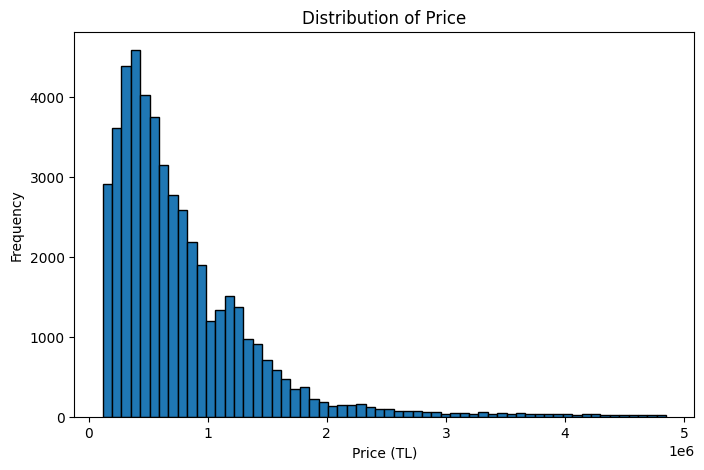

In [35]:
# Price distribution
df["price"].plot(kind="hist", bins=60, edgecolor="black")
plt.title("Distribution of Price")
plt.xlabel("Price (TL)")
plt.ylabel("Frequency")
plt.show()

Price histogram

The price distribution is clearly right-skewed, indicating that a relatively small number of expensive vehicles pull the distribution to the right.

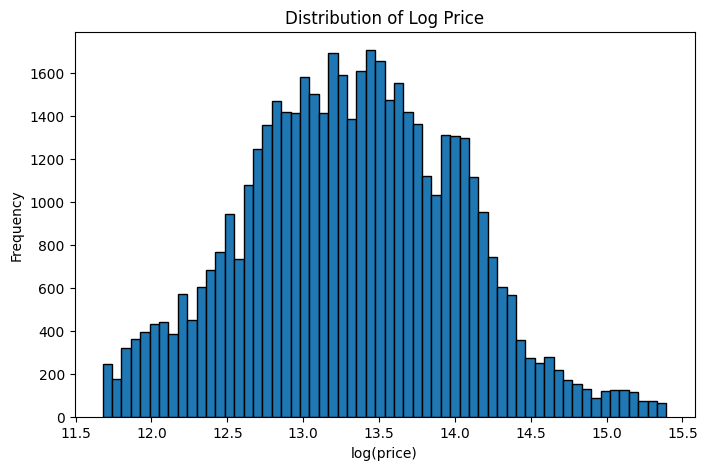

In [36]:
# Log-price distribution
df["log_price"].plot(kind="hist", bins=60, edgecolor="black")
plt.title("Distribution of Log Price")
plt.xlabel("log(price)")
plt.ylabel("Frequency")
plt.show()

Log-price histogram

After the logarithmic transformation, the price distribution becomes more symmetric, which supports the use of log-transformed price in later statistical analysis.

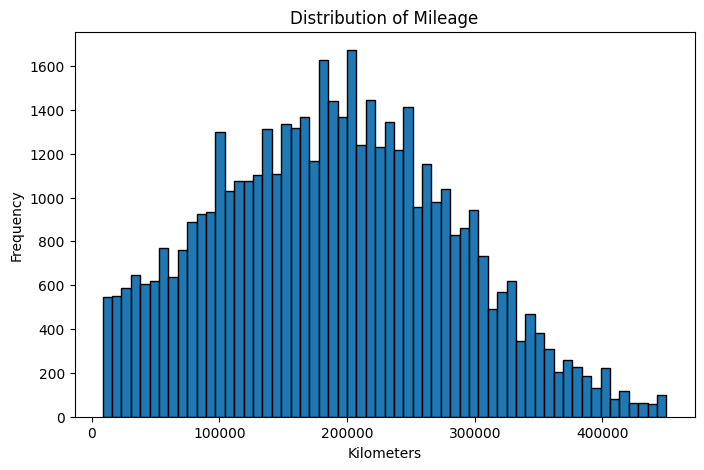

In [37]:
# Mileage distribution
df["km"].plot(kind="hist", bins=60, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Kilometers")
plt.ylabel("Frequency")
plt.show()

Km histogram

Mileage is concentrated at relatively high values, suggesting that the dataset mostly contains heavily used vehicles.

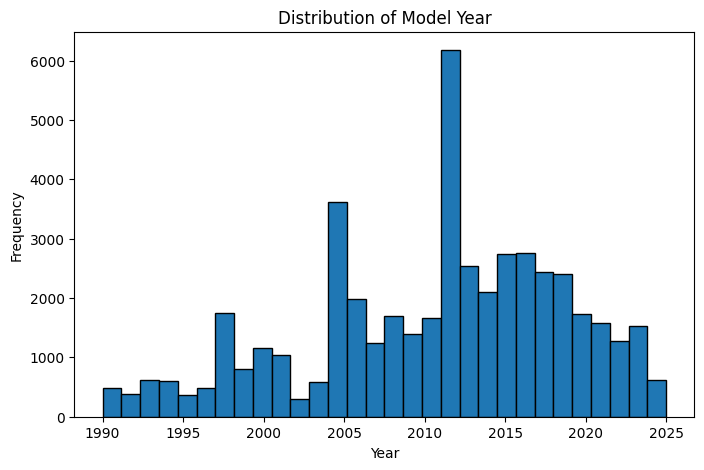

In [38]:
# Year distribution
df["year"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Distribution of Model Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

Year histogram

The distribution of production years indicates that the dataset contains both older and relatively recent vehicles, with stronger concentration around the 2000s and 2010s.

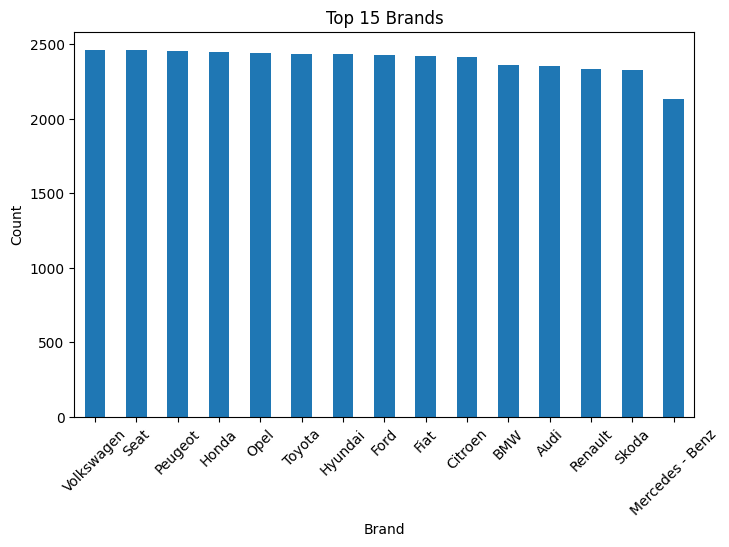

In [39]:
# Top brands
df["brand"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Brand bar chart

The dataset is dominated by a limited number of brands, which suggests that brand effects may play a substantial role in price formation.

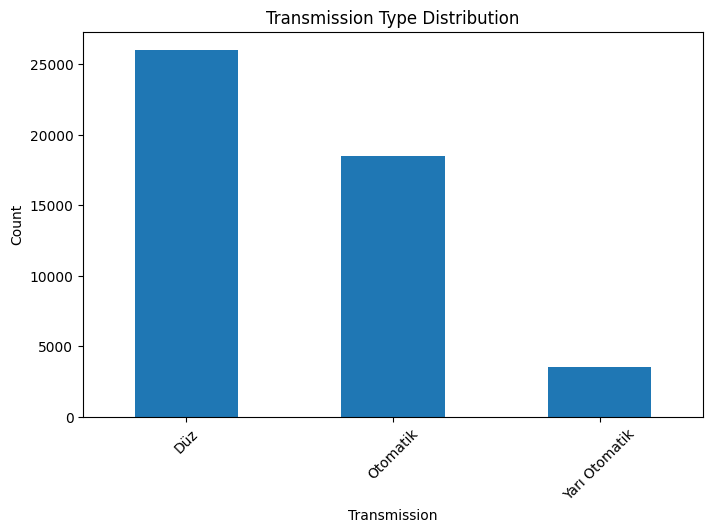

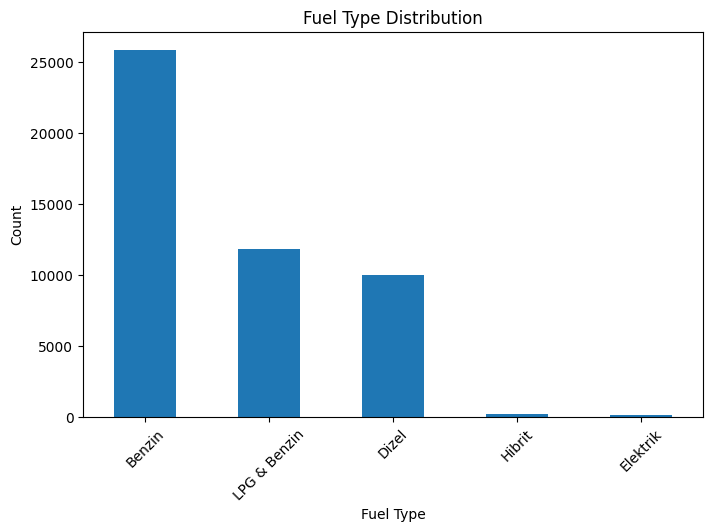

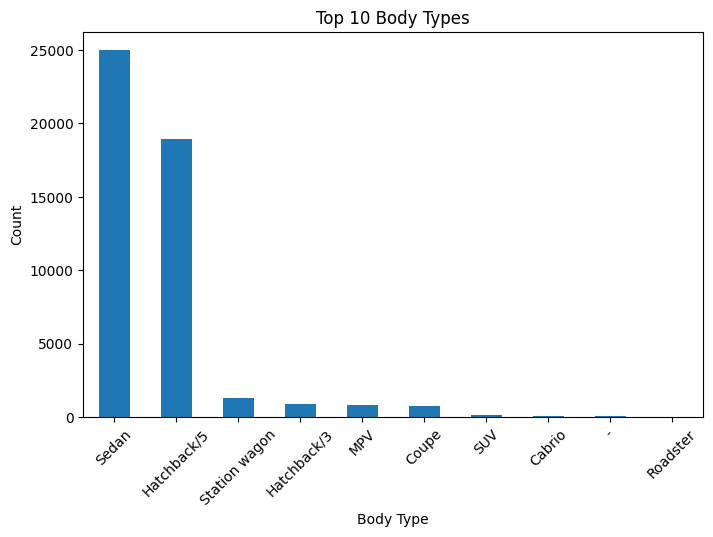

In [40]:
# Transmission types
df["transmission"].value_counts().plot(kind="bar")
plt.title("Transmission Type Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Fuel types
df["fuel"].value_counts().plot(kind="bar")
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Body types
df["body_type"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Body Types")
plt.xlabel("Body Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Boxplot by transmission / fuel / body type

Structural vehicle characteristics appear to create visible differences in price levels, suggesting stronger price effects than purely cosmetic variables.

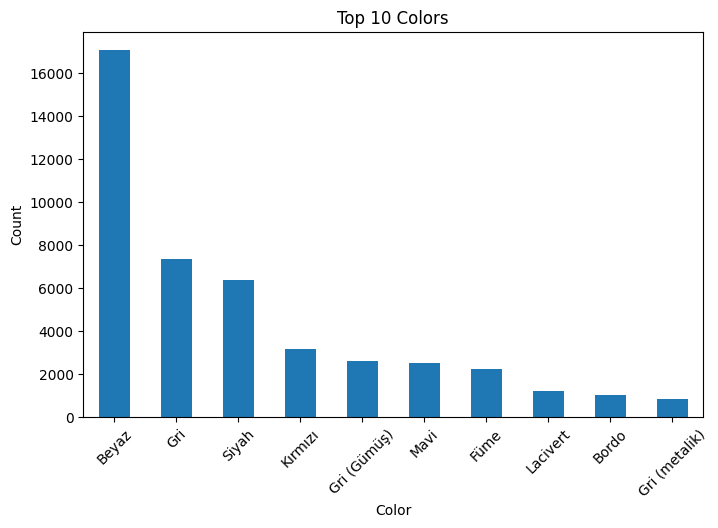

In [41]:
# Colors
df["color"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Colors")
plt.xlabel("Color")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Color bar chart

Some colors are much more common than others, which is important when interpreting the relationship between color and price.

In [42]:
sample_df = df.sample(min(5000, len(df)), random_state=42)

In scatter plots, too many points make the graph too crowded. Therefore, we randomly select a maximum of 5000 observations from the dataset. Using random_state=42 ensures that we take the same sample in every run.

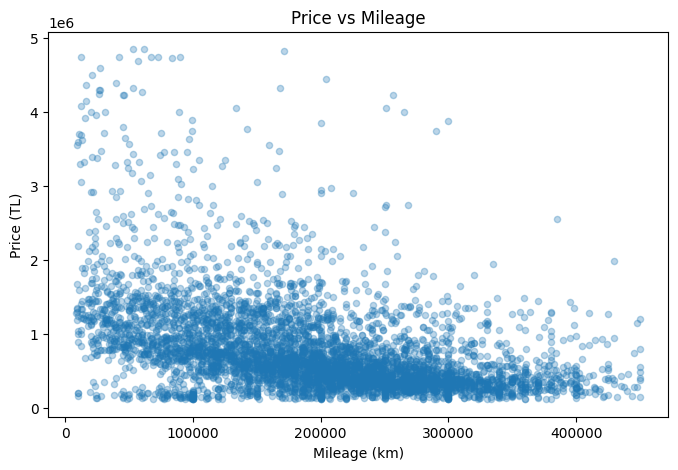

In [43]:
sample_df.plot.scatter(x="km", y="price", alpha=0.3)
plt.title("Price vs Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Price (TL)")
plt.show()

We are drawing a scatter plot to see the relationship between mileage and price. Objective: To observe whether the price tends to decrease as the mileage increases.

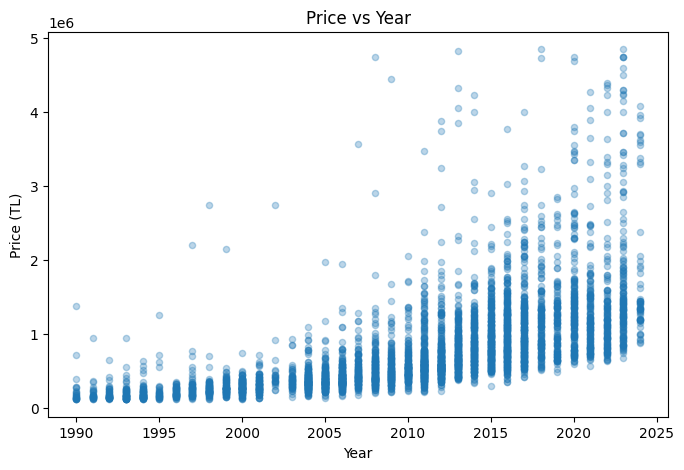

In [44]:
sample_df.plot.scatter(x="year", y="price", alpha=0.3)
plt.title("Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price (TL)")
plt.show()

We're drawing a scatter plot to see the relationship between vehicle year and price. The goal is to examine whether newer vehicles are generally more expensive.

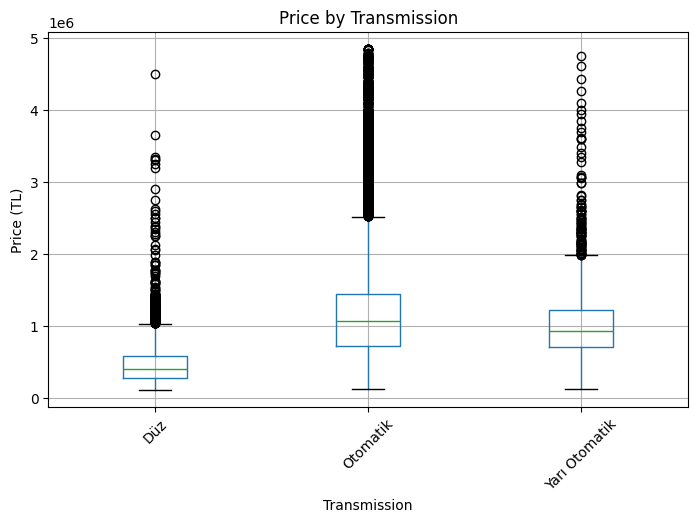

In [45]:
df.boxplot(column="price", by="transmission", rot=45)
plt.title("Price by Transmission")
plt.suptitle("")
plt.xlabel("Transmission")
plt.ylabel("Price (TL)")
plt.show()

We draw a boxplot to compare price distribution according to transmission type.
The boxplot allows us to see the median, quartiles, and outliers. This way, we can see if there are price differences between groups such as automatic/manual transmission.

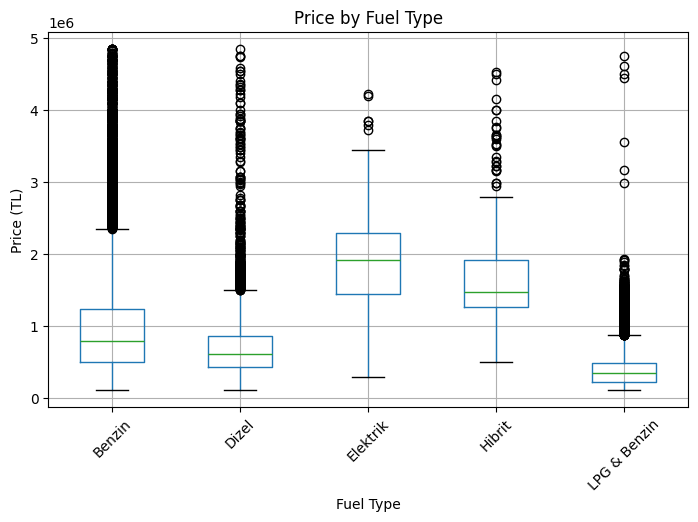

In [46]:
df.boxplot(column="price", by="fuel", rot=45)
plt.title("Price by Fuel Type")
plt.suptitle("")
plt.xlabel("Fuel Type")
plt.ylabel("Price (TL)")
plt.show()

We are comparing the price distribution according to fuel type. The aim is to see if there are differences in price levels among groups such as gasoline, diesel, LPG, hybrid, and electric.

In [47]:
top_body = df["body_type"].value_counts().head(8).index
df_body = df[df["body_type"].isin(top_body)]

There can be many categories in the case type variable. To keep the graph readable, we select the 8 most common case types.

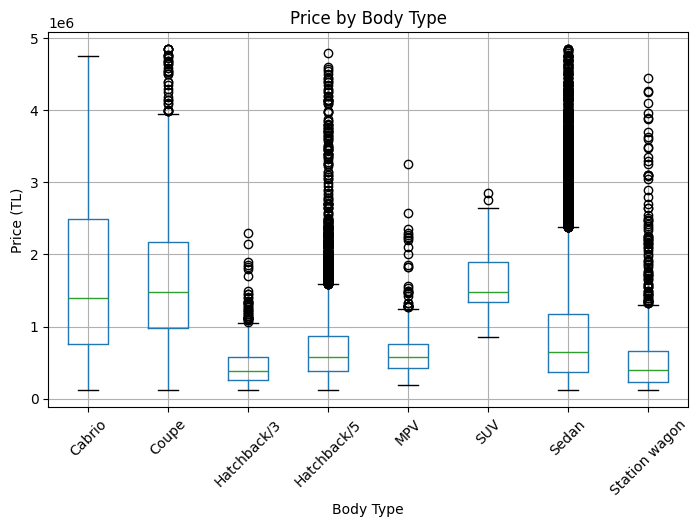

In [48]:
df_body.boxplot(column="price", by="body_type", rot=45)
plt.title("Price by Body Type")
plt.suptitle("")
plt.xlabel("Body Type")
plt.ylabel("Price (TL)")
plt.show()

We show the price distribution according to the most common body types selected using a boxplot. The aim is to examine the relationship between price and body types such as sedans, hatchbacks, SUVs, etc.

In [49]:
top_colors = df["color"].value_counts().head(8).index
df["color_group"] = np.where(df["color"].isin(top_colors), df["color"], "Other")


The color variable can also have many categories.
We separate the 8 most frequent colors and group the others under "Other".
This makes the graph simpler and easier to interpret.

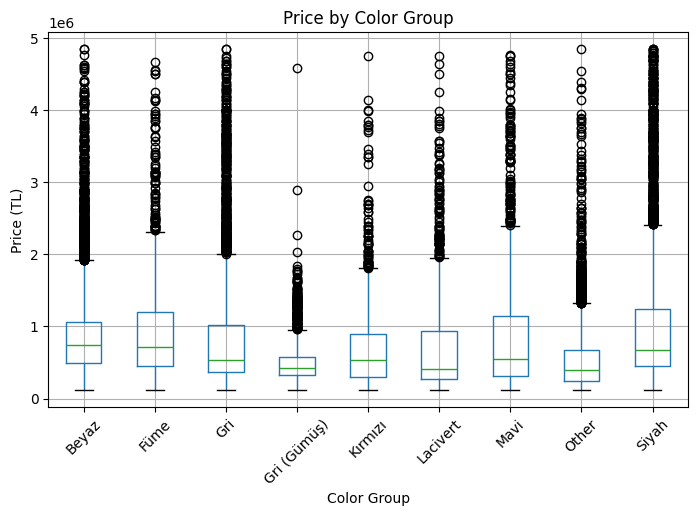

In [50]:
df.boxplot(column="price", by="color_group", rot=45)
plt.title("Price by Color Group")
plt.suptitle("")
plt.xlabel("Color Group")
plt.ylabel("Price (TL)")
plt.show()

We are displaying the price distribution according to color groups using a boxplot. This graph is directly related to the project question:
Is there a price difference between color groups in the raw data?

In [51]:
median_price_by_year = df.groupby("year")["price"].median().sort_index()

We calculate the median price for each year. Using the median makes you less affected by excessively expensive vehicles compared to the average.

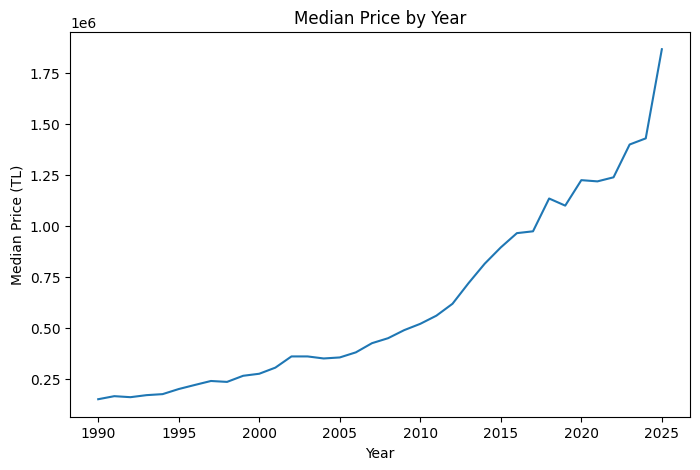

In [52]:
median_price_by_year.plot(kind="line")
plt.title("Median Price by Year")
plt.xlabel("Year")
plt.ylabel("Median Price (TL)")
plt.show()

We are plotting how the median price has changed over the years. The aim is to see the general trend in the price level of newer model vehicles.

In [53]:
# We print the top 10 most frequently seen brands.
# This helps us understand which brands the dataset is concentrated on.
print("Top 10 brands:")
print(df["brand"].value_counts().head(10))
print()


# We print the top 10 most common colors.
# This output allows us to see if the color distribution is uneven.
print("Top 10 colors:")
print(df["color"].value_counts().head(10))
print()

# We print the fuel type distribution.
# This way we can see which fuel types are dominant in the dataset.
print("Fuel type distribution:")
print(df["fuel"].value_counts())
print()


# We print the transmission type distribution.
# This allows us to understand the weight of categories like automatic/manual in the dataset.
print("Transmission distribution:")
print(df["transmission"].value_counts())



Top 10 brands:
brand
Volkswagen    2461
Seat          2460
Peugeot       2455
Honda         2449
Opel          2444
Toyota        2434
Hyundai       2434
Ford          2432
Fiat          2419
Citroen       2413
Name: count, dtype: int64

Top 10 colors:
color
Beyaz            17042
Gri               7319
Siyah             6354
Kırmızı           3155
Gri (Gümüş)       2611
Mavi              2517
Füme              2210
Lacivert          1214
Bordo             1009
Gri (metalik)      826
Name: count, dtype: int64

Fuel type distribution:
fuel
Benzin          25865
LPG & Benzin    11846
Dizel           10016
Hibrit            230
Elektrik          105
Name: count, dtype: int64

Transmission distribution:
transmission
Düz              26006
Otomatik         18504
Yarı Otomatik     3552
Name: count, dtype: int64


5. **Hypothesis Testing**

This section evaluates whether color has a statistically meaningful effect on used-car prices. The main hypothesis of the project is that cosmetic attributes, especially color, have only a limited marginal effect on price once the main structural characteristics of a vehicle are taken into account.

To examine this, the analysis is conducted in two stages. First, a nonparametric group comparison test is used to check whether raw price differences exist across color groups. This provides an initial view of whether prices vary by color at the descriptive level. Second, a regression-based hypothesis test is performed to determine whether color adds explanatory power after controlling for the core structural characteristics available in the dataset.

Because the dataset used in this project does not contain city information, the controlled analysis includes the available core variables: brand, series, year, mileage, fuel type, transmission type, and body type. The main null hypothesis is that color does not provide additional explanatory power once these variables are controlled for. In other words, the coefficients of the color categories are jointly equal to zero.

If the null hypothesis cannot be rejected, this supports the project expectation that color has only a limited role in price formation. If the null hypothesis is rejected but the improvement in model fit is very small, this would suggest that color may be statistically significant but practically weak.

In [54]:
# Nadir kategorileri "Other" altında toplamak için yardımcı fonksiyon
# Bu, hem grafikleri hem de regresyon modelini daha kararlı hale getirir.
def group_rare_categories(series, min_count=100):
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return pd.Series(np.where(series.isin(keep), series, "Other"), index=series.index)

# Hipotez testleri için gruplanmış kategoriler oluşturuyoruz.
df["color_group"] = group_rare_categories(df["color"], min_count=100)
df["body_group"] = group_rare_categories(df["body_type"], min_count=100)
df["series_group"] = group_rare_categories(df["series"], min_count=100)

# ---------------------------------------------------
# 1) Basit test: Ham düzeyde renk grupları arasında fark var mı?
# ---------------------------------------------------

valid_colors = df["color_group"].value_counts()
valid_colors = valid_colors[valid_colors >= 100].index

df_kw = df[df["color_group"].isin(valid_colors)].copy()

groups = [group["log_price"].values for _, group in df_kw.groupby("color_group")]

kw_stat, kw_p = stats.kruskal(*groups)

print("Kruskal-Wallis Test for Color Groups")
print(f"Statistic: {kw_stat:.4f}")
print(f"p-value (scientific notation): {kw_p:.3e}")
print(f"p-value (full): {kw_p}")
print()

# Ham düzeyde renk gruplarının medyan fiyatlarını görmek
print("Median price by color group:")
print(df_kw.groupby("color_group")["price"].median().sort_values(ascending=False))
print()

# ---------------------------------------------------
# 2) Ana test: Kontrollü regresyon ile color'ın ek katkısını test et
# H0: Color kategorilerinin katsayıları birlikte sıfırdır
# ---------------------------------------------------

reg_cols = [
    "log_price", "year", "log_km",
    "brand", "series_group", "fuel",
    "transmission", "body_group", "color_group"
]

df_reg = df[reg_cols].dropna().copy()

# Restricted model: color yok
formula_restricted = """
log_price ~ year + log_km
+ C(brand)
+ C(series_group)
+ C(fuel)
+ C(transmission)
+ C(body_group)
"""

# Full model: color eklendi
formula_full = """
log_price ~ year + log_km
+ C(brand)
+ C(series_group)
+ C(fuel)
+ C(transmission)
+ C(body_group)
+ C(color_group)
"""

# Modelleri kur
m0 = smf.ols(formula_restricted, data=df_reg).fit()
m1 = smf.ols(formula_full, data=df_reg).fit()

# İç içe modelleri karşılaştır
comparison = anova_lm(m0, m1)

# Artık comparison oluştuğu için burada yazdırıyoruz
print("Nested model p-value:")
print(comparison.loc[1, "Pr(>F)"])
print(f"Nested model p-value (scientific notation): {comparison.loc[1, 'Pr(>F)']:.3e}")
print()

print("Nested Model Comparison (Restricted vs Full)")
print(comparison)
print()

print("Restricted model adjusted R^2:", round(m0.rsquared_adj, 5))
print("Full model adjusted R^2:", round(m1.rsquared_adj, 5))
print("Delta adjusted R^2:", round(m1.rsquared_adj - m0.rsquared_adj, 5))
print()

print("Restricted model AIC:", round(m0.aic, 2))
print("Full model AIC:", round(m1.aic, 2))
print()

# Color katsayılarını ayrıca göster
color_mask = m1.params.index.str.contains(r"C\(color_group\)")
color_results = pd.DataFrame({
    "coef": m1.params[color_mask],
    "p_value": m1.pvalues[color_mask]
}).sort_values("p_value")

print("Color coefficients in the full model:")
print(color_results)

Kruskal-Wallis Test for Color Groups
Statistic: 4810.1383
p-value (scientific notation): 0.000e+00
p-value (full): 0.0

Median price by color group:
color_group
Turuncu            800000.0
Beyaz              739975.0
Füme               715000.0
Siyah              675250.0
Kahverengi         675000.0
Gri (titanyum)     670000.0
Mavi               550000.0
Kırmızı            538750.0
Gri                530000.0
Gri (metalik)      487500.0
Mavi (metalik)     445000.0
Gri (Gümüş)        420000.0
Bej                420000.0
Lacivert           410000.0
Şampanya           396000.0
Sarı               372500.0
Other              349500.0
Diğer              337500.0
Bordo              292000.0
Yeşil (metalik)    280500.0
Yeşil              279500.0
Turkuaz            238500.0
Name: price, dtype: float64

Nested model p-value:
2.1426305252590204e-14
Nested model p-value (scientific notation): 2.143e-14

Nested Model Comparison (Restricted vs Full)
   df_resid          ssr  df_diff   ss_diff      

***Hypothesis Test Results***

The hypothesis tests show that color is related to used-car prices, but its practical importance appears to be very limited. First, the Kruskal–Wallis test comparing price distributions across color groups produced a test statistic of 4810.14 with a p-value effectively equal to zero (reported numerically as 0.0 due to underflow), indicating that raw price differences across color groups are statistically significant. However, this initial result does not control for other important characteristics such as brand, series, year, mileage, fuel type, transmission, and body type. To address this, a nested regression model comparison was conducted between a restricted model without color and a full model including color. This comparison yielded a highly significant p-value of 2.14 × 10⁻¹⁴, meaning that the null hypothesis that all color coefficients are jointly equal to zero can be rejected. In statistical terms, color does add explanatory power to the model after controlling for structural vehicle characteristics. Nevertheless, the practical contribution of color remains extremely small: the adjusted R² increased only from 0.92648 to 0.92662, corresponding to a change of just 0.00014. Therefore, although color is statistically significant, its marginal effect on used-car prices is very weak in substantive terms. Overall, these findings support the project’s main expectation that cosmetic attributes such as color have only a limited role in price formation compared with core structural characteristics.

**Data Enrichment**

As an additional enrichment step, the dataset was combined with official 2026 Motor Vehicle Tax (MTV) information published by the Revenue Administration of Türkiye (GİB). This enrichment was selected because the original used-car dataset does not include a listing date, which makes date-based external variables such as exchange rates or fuel prices difficult to match consistently at the observation level. In contrast, the official MTV structure depends on engine cylinder volume, vehicle age, and vehicle value brackets, which can be approximated using variables available in the dataset. To construct this feature, vehicle age was derived from the production year, engine-volume categories were created from the engine displacement variable, and an estimated annual MTV amount was assigned based on the official tax table. Since the dataset does not provide the exact official vehicle-value field used in the legal tariff, listing price was used as a proxy for the value bracket. Therefore, this variable is interpreted as an estimated ownership-cost indicator rather than the exact legal tax amount.

In [55]:

# Araç yaşını hesapla
df["vehicle_age"] = 2026 - df["year"]

# Yaş grubu oluştur
def age_bracket(age):
    if pd.isna(age):
        return np.nan
    elif age <= 3:
        return "1-3"
    elif age <= 6:
        return "4-6"
    elif age <= 11:
        return "7-11"
    elif age <= 15:
        return "12-15"
    else:
        return "16+"

# Motor hacmi grubu oluştur
def engine_bracket(cc):
    if pd.isna(cc):
        return np.nan
    elif cc <= 1300:
        return "<=1300"
    elif cc <= 1600:
        return "1301-1600"
    elif cc <= 1800:
        return "1601-1800"
    elif cc <= 2000:
        return "1801-2000"
    elif cc <= 2500:
        return "2001-2500"
    elif cc <= 3000:
        return "2501-3000"
    elif cc <= 3500:
        return "3001-3500"
    elif cc <= 4000:
        return "3501-4000"
    else:
        return "4001+"

# Taşıt değeri grubu oluştur
# Burada price değişkeni taşıt değeri için proxy olarak kullanılıyor.
def value_bracket_proxy(price, eng_br):
    if pd.isna(price) or pd.isna(eng_br):
        return np.nan

    if eng_br in ["<=1300", "1301-1600"]:
        if price <= 309100:
            return "low"
        elif price <= 541500:
            return "mid"
        else:
            return "high"

    elif eng_br in ["1601-1800", "1801-2000"]:
        if price <= 775100:
            return "low"
        else:
            return "high"

    elif eng_br == "2001-2500":
        if price <= 968100:
            return "low"
        else:
            return "high"

    elif eng_br in ["2501-3000", "3001-3500"]:
        if price <= 1937500:
            return "low"
        else:
            return "high"

    elif eng_br == "3501-4000":
        if price <= 3101800:
            return "low"
        else:
            return "high"

    elif eng_br == "4001+":
        if price <= 3683200:
            return "low"
        else:
            return "high"

    return np.nan

df["age_bracket"] = df["vehicle_age"].apply(age_bracket)
df["engine_bracket"] = df["engine_volume"].apply(engine_bracket)
df["value_bracket_proxy"] = df.apply(
    lambda row: value_bracket_proxy(row["price"], row["engine_bracket"]),
    axis=1
)

# 2026 MTV tablosu
mtv_table = pd.DataFrame([
    # <=1300
    {"engine_bracket": "<=1300", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 5750},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 4010},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 2238},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 1689},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 593},

    {"engine_bracket": "<=1300", "value_bracket_proxy": "mid",  "age_bracket": "1-3",   "mtv_estimated_2026": 6319},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "mid",  "age_bracket": "4-6",   "mtv_estimated_2026": 4409},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "mid",  "age_bracket": "7-11",  "mtv_estimated_2026": 2459},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "mid",  "age_bracket": "12-15", "mtv_estimated_2026": 1861},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "mid",  "age_bracket": "16+",   "mtv_estimated_2026": 655},

    {"engine_bracket": "<=1300", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 6902},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 4807},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 2693},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 2032},
    {"engine_bracket": "<=1300", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 706},

    # 1301-1600
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 10016},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 7510},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 4354},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 3077},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 1181},

    {"engine_bracket": "1301-1600", "value_bracket_proxy": "mid",  "age_bracket": "1-3",   "mtv_estimated_2026": 11023},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "mid",  "age_bracket": "4-6",   "mtv_estimated_2026": 8264},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "mid",  "age_bracket": "7-11",  "mtv_estimated_2026": 4794},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "mid",  "age_bracket": "12-15", "mtv_estimated_2026": 3375},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "mid",  "age_bracket": "16+",   "mtv_estimated_2026": 1290},

    {"engine_bracket": "1301-1600", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 12028},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 9012},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 5220},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 3685},
    {"engine_bracket": "1301-1600", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 1408},

    # 1601-1800
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 19472},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 15226},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 8948},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 5458},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 2113},

    {"engine_bracket": "1601-1800", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 21251},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 16600},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 9775},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 5964},
    {"engine_bracket": "1601-1800", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 2307},

    # 1801-2000
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 30679},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 23625},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 13886},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 8264},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 3248},

    {"engine_bracket": "1801-2000", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 33474},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 25784},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 15147},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 9012},
    {"engine_bracket": "1801-2000", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 3547},

    # 2001-2500
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 46027},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 33413},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 20874},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 12465},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 4930},

    {"engine_bracket": "2001-2500", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 50217},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 36448},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 22768},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 13606},
    {"engine_bracket": "2001-2500", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 5378},

    # 2501-3000
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 64175},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 55837},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 34878},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 18758},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 6875},

    {"engine_bracket": "2501-3000", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 70018},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 60905},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 38053},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 20466},
    {"engine_bracket": "2501-3000", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 7503},

    # 3001-3500
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 97744},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 87954},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 52976},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 26443},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 9684},

    {"engine_bracket": "3001-3500", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 106641},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 95940},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 57791},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 28839},
    {"engine_bracket": "3001-3500", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 10578},

    # 3501-4000
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 153684},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 132712},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 78152},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 34878},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 13886},

    {"engine_bracket": "3501-4000", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 167671},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 144770},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 85271},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 38053},
    {"engine_bracket": "3501-4000", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 15147},

    # 4001+
    {"engine_bracket": "4001+", "value_bracket_proxy": "low",  "age_bracket": "1-3",   "mtv_estimated_2026": 251554},
    {"engine_bracket": "4001+", "value_bracket_proxy": "low",  "age_bracket": "4-6",   "mtv_estimated_2026": 188627},
    {"engine_bracket": "4001+", "value_bracket_proxy": "low",  "age_bracket": "7-11",  "mtv_estimated_2026": 111714},
    {"engine_bracket": "4001+", "value_bracket_proxy": "low",  "age_bracket": "12-15", "mtv_estimated_2026": 50206},
    {"engine_bracket": "4001+", "value_bracket_proxy": "low",  "age_bracket": "16+",   "mtv_estimated_2026": 19472},

    {"engine_bracket": "4001+", "value_bracket_proxy": "high", "age_bracket": "1-3",   "mtv_estimated_2026": 274415},
    {"engine_bracket": "4001+", "value_bracket_proxy": "high", "age_bracket": "4-6",   "mtv_estimated_2026": 205781},
    {"engine_bracket": "4001+", "value_bracket_proxy": "high", "age_bracket": "7-11",  "mtv_estimated_2026": 121873},
    {"engine_bracket": "4001+", "value_bracket_proxy": "high", "age_bracket": "12-15", "mtv_estimated_2026": 54769},
    {"engine_bracket": "4001+", "value_bracket_proxy": "high", "age_bracket": "16+",   "mtv_estimated_2026": 21251},
])

# MTV tablosunu merge et
df = df.merge(
    mtv_table,
    on=["engine_bracket", "value_bracket_proxy", "age_bracket"],
    how="left"
)

# Özet tablo
summary_cols = ["price", "km", "year", "log_price", "log_km", "mtv_estimated_2026"]
summary = df[summary_cols].describe()

summary["price"] = summary["price"].map(lambda x: f"{x:,.0f}" if pd.notnull(x) else x)
summary["km"] = summary["km"].map(lambda x: f"{x:,.0f}" if pd.notnull(x) else x)
summary["year"] = summary["year"].map(lambda x: f"{x:,.0f}" if pd.notnull(x) else x)
summary["log_price"] = summary["log_price"].map(lambda x: f"{x:.3f}" if pd.notnull(x) else x)
summary["log_km"] = summary["log_km"].map(lambda x: f"{x:.3f}" if pd.notnull(x) else x)
summary["mtv_estimated_2026"] = summary["mtv_estimated_2026"].map(lambda x: f"{x:,.0f}" if pd.notnull(x) else x)

print(summary)
print()

print("Missing values after enrichment:")
print(df.isna().sum().sort_values(ascending=False))
print()

print("Rows with estimated MTV:")
print(df["mtv_estimated_2026"].notna().sum())
print()

print("MTV summary by engine bracket:")
print(df.groupby("engine_bracket")["mtv_estimated_2026"].describe())

           price       km    year  log_price     log_km mtv_estimated_2026
count     48,062   48,062  48,062  48062.000  48062.000             46,947
mean     783,217  190,004   2,011     13.322     11.984              4,076
std      621,655   92,584       8      0.704      0.674              4,379
min      118,000    8,700   1,990     11.678      9.071                593
25%      370,000  120,000   2,005     12.821     11.695              1,290
50%      610,000  190,000   2,012     13.321     12.155              3,375
75%      995,000  255,000   2,016     13.810     12.449              5,220
max    4,850,000  450,000   2,025     15.394     13.017            188,627

Missing values after enrichment:
changed_parts          9469
painted_parts          9469
engine_power           1252
engine_volume          1115
engine_bracket         1115
mtv_estimated_2026     1115
value_bracket_proxy    1115
series                    0
id                        0
brand                     0
color      

The histogram suggests that estimated MTV values are concentrated in lower tax ranges, while relatively few vehicles fall into very high tax brackets.

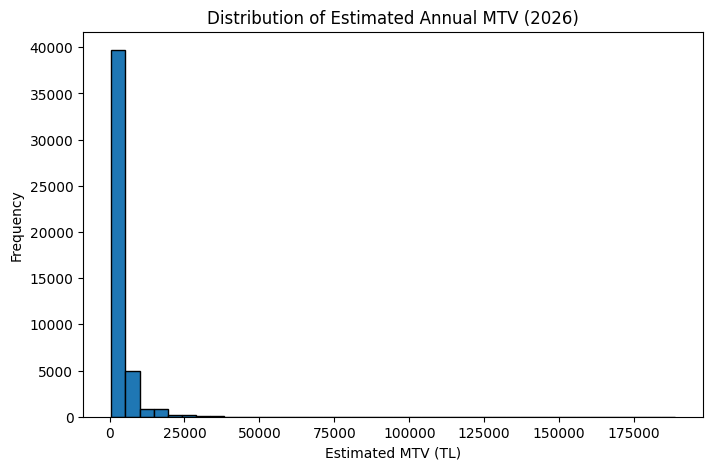

In [56]:
# Estimated MTV distribution
df["mtv_estimated_2026"].dropna().plot(kind="hist", bins=40, edgecolor="black")
plt.title("Distribution of Estimated Annual MTV (2026)")
plt.xlabel("Estimated MTV (TL)")
plt.ylabel("Frequency")
plt.show()

The scatter plot indicates a positive relationship between estimated MTV and vehicle price, although this pattern should be interpreted carefully because price is also used as a proxy in constructing the estimated MTV variable.

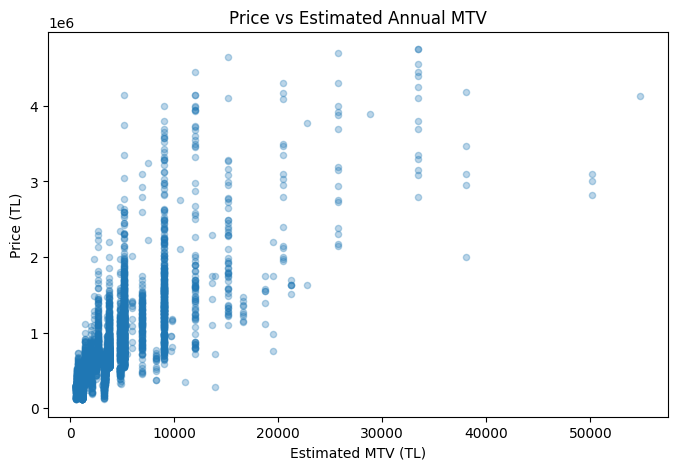

In [57]:
# Sample for scatter plot to keep the graph readable
df_mtv = df.dropna(subset=["mtv_estimated_2026"]).copy()
sample_mtv = df_mtv.sample(min(5000, len(df_mtv)), random_state=42)

sample_mtv.plot.scatter(x="mtv_estimated_2026", y="price", alpha=0.3)
plt.title("Price vs Estimated Annual MTV")
plt.xlabel("Estimated MTV (TL)")
plt.ylabel("Price (TL)")
plt.show()